## 1️⃣ Setup & Load Data

In [ ]:
!pip install geopandas matplotlib mapclassify

In [ ]:
# ติดตั้ง library เพิ่มเติม (ถ้าจำเป็น)
!pip install plotly kaleido -q

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import geopandas as gpd
import urllib.request
import matplotlib.patheffects as pe
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

#ดาวน์โหลดฟอนต์ภาษาไทย (TH Sarabun New)
!wget -q https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf
#เพิ่มฟอนต์เข้าไปในระบบ
mpl.font_manager.fontManager.addfont('thsarabunnew-webfont.ttf')
mpl.rc('font', family='TH Sarabun New', size=16)
sns.set_theme(style="whitegrid", font="TH Sarabun New")

# ตั้งค่า style
plt.rcParams['figure.dpi'] = 120

print('✅ Import สำเร็จ! พร้อมวิเคราะห์ข้อมูลแล้ว 🚀')

✅ Import สำเร็จ! พร้อมวิเคราะห์ข้อมูลแล้ว 🚀


In [ ]:
#plt.rcParams["figure.figsize"] = (10, 6)
#sns.set_style("whitegrid")

In [ ]:
# load
df = pd.read_csv('fire.csv', encoding='utf-8-sig')

# preview
df.head()

,province,event_count,district,subdistrict_count,village_count,local_admin_count,community_count,population,households,fatalities_count,...,shops,buildings,temporary_shelter,landfill_area,vehicles,religious_buildings,schools,government_offices,others,property_damage_cost
0,จังหวัด,จำนวนครั้ง,อำเภอ,จำนวนตำบล,จำนวนหมู่บ้าน,จำนวนอปท.,จำนวนชุมชน,ราษฎร(คน),ราษฎร(ครัวเรือน),ราษฎรเสียชีวิต(คน),...,ร้านค้า (หลัง),อาคาร/สิ่งก่อสร้าง,ที่พักชั่วคราว (แห่ง),บ่อขยะ (ไร่),ยานยนต์(คัน),ศาสนสถาน(แห่ง),โรงเรียน(แห่ง),สถานที่ราชการ(แห่ง),อื่นๆ,มูลค่าความเสียหายด้านทรัพย์สินของราษฎร(บาท)
1,กระบี่,3,2,5,7,-,-,4,4,-,...,-,-,-,-,-,-,-,1,-,-
2,กาญจนบุรี,7,7,7,5,-,-,64,38,-,...,-,-,-,-,-,-,-,-,-,"6,738,000"
3,กาฬสินธุ์,40,14,30,40,1,1,182,55,1,...,-,-,1,-,10,1,-,-,2,"12,973,690"
4,ขอนแก่น,28,13,25,30,-,-,95,32,-,...,-,-,-,-,-,-,-,3,2,"6,243,886"


## 2️⃣ First Look — EDA เบื้องต้น

In [ ]:
# ============================================
# สถิติเบื้องต้นของไฟล์ข้อมูลดิบ (ไม่ผ่านการ Clean)
# ============================================
df_raw = df

row_count = df_raw.shape[0]
col_count = df_raw.shape[1]
null_count = df_raw.isnull().sum().sum()

province_count = df_raw["province"].nunique(dropna=True)

print("📂 สถิติเบื้องต้นของไฟล์ข้อมูลดิบ")
print(f"📑 จำนวนแถวทั้งหมด              : {row_count:>12,} แถว")
print(f"📊 จำนวนคอลัมน์ทั้งหมด          : {col_count:>12,} คอลัมน์")
print(f"📍 จำนวนจังหวัด (ไม่นับค่าว่าง)   : {province_count:>12,} จังหวัด")
print(f"⚠️ ค่า Missing แบบ NaN          : {null_count:>12,} ค่า")

📂 สถิติเบื้องต้นของไฟล์ข้อมูลดิบ
📑 จำนวนแถวทั้งหมด              :           72 แถว
📊 จำนวนคอลัมน์ทั้งหมด          :           34 คอลัมน์
📍 จำนวนจังหวัด (ไม่นับค่าว่าง)   :           70 จังหวัด
⚠️ ค่า Missing แบบ NaN          :          167 ค่า


## 3️⃣ Data Quality & Cleaning 🧹

In [ ]:
#Clean
df_clean = df.copy()

#ลบ header ซ้ำ
df_clean = df_clean.iloc[1:].reset_index(drop=True)

#ตัดช่องว่างหน้า-หลัง
df_clean = df_clean.applymap(lambda x: x.strip() if isinstance(x, str) else x)

#แทน missing token เป็น NaN
df_clean = df_clean.replace(["-", "##", "", "null", "Null", "NULL"], np.nan)

#ระบุ text / numeric cols
text_cols = ["province"]
numeric_cols = [col for col in df_clean.columns if col not in text_cols]

#clean คอลัมน์ตัวเลข
for col in numeric_cols:
    df_clean[col] = df_clean[col].astype(str).str.replace(",", "", regex=False)
    df_clean[col] = df_clean[col].replace("nan", np.nan)
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

#เติม missing ของ text
df_clean["province"] = df_clean["province"].fillna("ไม่ระบุจังหวัด")

#เติม median (สำคัญ)
for col in numeric_cols:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)

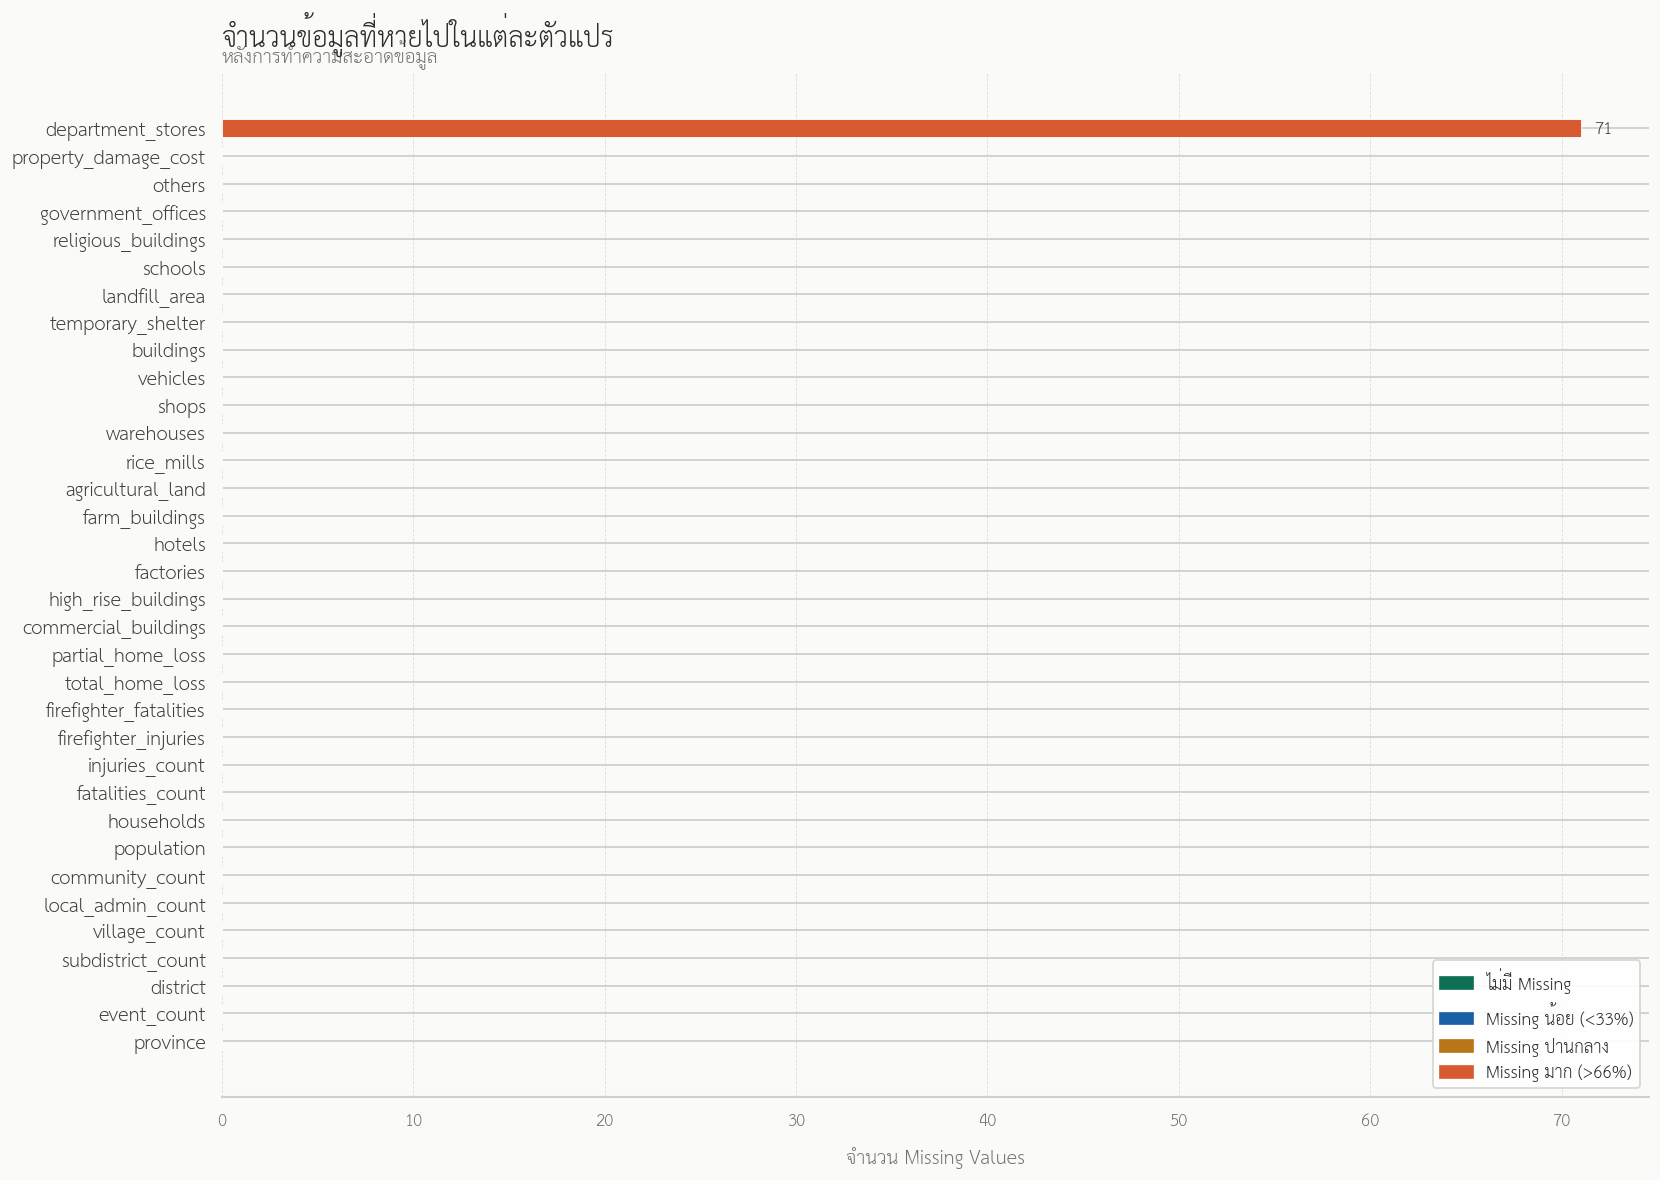

In [ ]:
#กราฟหลังจากการ Clean
data = df_clean.isnull().sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(14, 10))
fig.patch.set_facecolor('#FAFAF8')
ax.set_facecolor('#FAFAF8')

max_val = data.max()

def get_color(val):
    if val == 0:
        return '#0F6E56'
    ratio = val / max_val if max_val > 0 else 0
    if ratio < 0.33:
        return '#185FA5'
    elif ratio < 0.66:
        return '#BA7517'
    else:
        return '#D85A30'

colors = [get_color(v) for v in data.values]

bars = ax.barh(
    data.index,
    data.values,
    color=colors,
    height=0.65,
    edgecolor='white',
    linewidth=0.5,
)

for bar, val in zip(bars, data.values):
    if val > 0:
        ax.text(
            val + max_val * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{int(val):,}',
            va='center',
            ha='left',
            fontsize=10,
            color='#444441',
            fontweight='500'
        )

ax.set_title(
    'จำนวนข้อมูลที่หายไปในแต่ละตัวแปร',
    fontsize=16,
    fontweight='600',
    color='#2C2C2A',
    pad=16,
    loc='left'
)

ax.text(
    0, 1.01,
    'หลังการทำความสะอาดข้อมูล',
    transform=ax.transAxes,
    fontsize=11,
    color='#73726c'
)

ax.set_xlabel('จำนวน Missing Values', fontsize=11, color='#73726c', labelpad=10)
ax.xaxis.grid(True, linestyle='--', linewidth=0.5, color='#D3D1C7', alpha=0.7)
ax.set_axisbelow(True)

ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color('#D3D1C7')

ax.tick_params(axis='y', colors='#3d3d3a', labelsize=11)
ax.tick_params(axis='x', colors='#73726c', labelsize=10)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

legend_items = [
    mpatches.Patch(color='#0F6E56', label='ไม่มี Missing'),
    mpatches.Patch(color='#185FA5', label='Missing น้อย (<33%)'),
    mpatches.Patch(color='#BA7517', label='Missing ปานกลาง'),
    mpatches.Patch(color='#D85A30', label='Missing มาก (>66%)'),
]
ax.legend(handles=legend_items, loc='lower right', fontsize=10,
          framealpha=0.9, edgecolor='#D3D1C7')

plt.tight_layout()
plt.savefig('df_clean_missing.png', dpi=150, bbox_inches='tight')
plt.show()

## 4️⃣ Feature Engineering

In [ ]:
#เลือกเฉพาะข้อมูลระดับจังหวัด
#ตัดแถวสรุปรวมออก เพื่อให้เหลือข้อมูลจังหวัดจริง
df_q2 = df_clean[
    ~df_clean['province'].str.contains('รวม', na=False)
].copy()

#สร้าง Mapping จังหวัด -> ภูมิภาค
#ใช้สำหรับวิเคราะห์ระดับภูมิภาค
region_mapping = {
    'เชียงใหม่': 'เหนือ', 'เชียงราย': 'เหนือ', 'ลำปาง': 'เหนือ', 'ลำพูน': 'เหนือ',
    'แม่ฮ่องสอน': 'เหนือ', 'พะเยา': 'เหนือ', 'แพร่': 'เหนือ', 'น่าน': 'เหนือ',
    'อุตรดิตถ์': 'เหนือ',

    'นครสวรรค์': 'กลาง', 'อุทัยธานี': 'กลาง', 'กำแพงเพชร': 'กลาง', 'ชัยนาท': 'กลาง',
    'สิงห์บุรี': 'กลาง', 'ลพบุรี': 'กลาง', 'อ่างทอง': 'กลาง', 'พระนครศรีอยุธยา': 'กลาง',
    'สระบุรี': 'กลาง', 'นนทบุรี': 'กลาง', 'ปทุมธานี': 'กลาง', 'นครปฐม': 'กลาง',
    'สมุทรปราการ': 'กลาง', 'สมุทรสาคร': 'กลาง', 'สมุทรสงคราม': 'กลาง',
    'กรุงเทพมหานคร': 'กลาง', 'สุโขทัย': 'กลาง', 'พิษณุโลก': 'กลาง', 'พิจิตร': 'กลาง',
    'เพชรบูรณ์': 'กลาง', 'สุพรรณบุรี': 'กลาง', 'นครนายก': 'กลาง',

    'นครราชสีมา': 'ตะวันออกเฉียงเหนือ', 'บุรีรัมย์': 'ตะวันออกเฉียงเหนือ',
    'สุรินทร์': 'ตะวันออกเฉียงเหนือ', 'ศรีสะเกษ': 'ตะวันออกเฉียงเหนือ',
    'อุบลราชธานี': 'ตะวันออกเฉียงเหนือ', 'ยโสธร': 'ตะวันออกเฉียงเหนือ',
    'ชัยภูมิ': 'ตะวันออกเฉียงเหนือ', 'อำนาจเจริญ': 'ตะวันออกเฉียงเหนือ',
    'บึงกาฬ': 'ตะวันออกเฉียงเหนือ', 'หนองบัวลำภู': 'ตะวันออกเฉียงเหนือ',
    'ขอนแก่น': 'ตะวันออกเฉียงเหนือ', 'อุดรธานี': 'ตะวันออกเฉียงเหนือ',
    'เลย': 'ตะวันออกเฉียงเหนือ', 'หนองคาย': 'ตะวันออกเฉียงเหนือ',
    'มหาสารคาม': 'ตะวันออกเฉียงเหนือ', 'ร้อยเอ็ด': 'ตะวันออกเฉียงเหนือ',
    'กาฬสินธุ์': 'ตะวันออกเฉียงเหนือ', 'สกลนคร': 'ตะวันออกเฉียงเหนือ',
    'นครพนม': 'ตะวันออกเฉียงเหนือ', 'มุกดาหาร': 'ตะวันออกเฉียงเหนือ',

    'ตาก': 'ตะวันตก', 'ราชบุรี': 'ตะวันตก', 'กาญจนบุรี': 'ตะวันตก',
    'เพชรบุรี': 'ตะวันตก', 'ประจวบคีรีขันธ์': 'ตะวันตก',

    'ปราจีนบุรี': 'ตะวันออก', 'สระแก้ว': 'ตะวันออก', 'ฉะเชิงเทรา': 'ตะวันออก',
    'ชลบุรี': 'ตะวันออก', 'ระยอง': 'ตะวันออก', 'จันทบุรี': 'ตะวันออก',
    'ตราด': 'ตะวันออก',

    'ชุมพร': 'ใต้', 'ระนอง': 'ใต้', 'สุราษฎร์ธานี': 'ใต้', 'พังงา': 'ใต้',
    'ภูเก็ต': 'ใต้', 'กระบี่': 'ใต้', 'นครศรีธรรมราช': 'ใต้', 'ตรัง': 'ใต้',
    'พัทลุง': 'ใต้', 'สงขลา': 'ใต้', 'สตูล': 'ใต้', 'ปัตตานี': 'ใต้',
    'ยะลา': 'ใต้', 'นราธิวาส': 'ใต้'
}

#เพิ่มคอลัมน์ภูมิภาค
#จังหวัดที่ไม่อยู่ใน mapping จะถูกระบุเป็น 'ไม่ระบุ'
df_q2['region'] = df_q2['province'].map(region_mapping).fillna('ไม่ระบุ')

#กำหนดประเภทสิ่งปลูกสร้าง
building_types = [
    'total_home_loss', 'partial_home_loss', 'commercial_buildings', 'factories',
    'hotels', 'farm_buildings', 'department_stores', 'rice_mills', 'warehouses',
    'shops', 'buildings', 'temporary_shelter', 'religious_buildings', 'schools',
    'government_offices'
]

#เปลี่ยนชื่อคอลัมน์สิ่งปลูกสร้างเป็นภาษาไทย
#ใช้ใน legend / treemap / การสรุปผล
building_labels_th = {
    'total_home_loss': 'บ้านเรือนเสียหายทั้งหลัง',
    'partial_home_loss': 'บ้านเรือนเสียหายบางส่วน',
    'commercial_buildings': 'อาคารพาณิชย์',
    'factories': 'โรงงาน',
    'hotels': 'โรงแรม',
    'farm_buildings': 'สิ่งปลูกสร้างเกษตร',
    'department_stores': 'ห้างสรรพสินค้า',
    'rice_mills': 'โรงสี',
    'warehouses': 'โกดัง',
    'shops': 'ร้านค้า',
    'buildings': 'อาคาร',
    'temporary_shelter': 'ที่พักชั่วคราว',
    'religious_buildings': 'ศาสนสถาน',
    'schools': 'โรงเรียน',
    'government_offices': 'สถานที่ราชการ'
}

In [ ]:
#เลือกคอลัมน์ที่ใช้ตอบคำถามเรื่อง "ความเสี่ยงจริง"
#ใช้เฉพาะจังหวัด + จำนวนเหตุ + มูลค่าความเสียหาย
df_q1 = df_q2[['province', 'event_count', 'property_damage_cost']].copy()

#แปลงหน่วยมูลค่าความเสียหายจาก "บาท" -> "ล้านบาท"
#เพื่อให้กราฟอ่านง่ายขึ้น
df_q1['property_damage_cost_million'] = df_q1['property_damage_cost'] / 1_000_000

#หา median ของจำนวนเหตุการณ์และความเสียหาย
#ใช้เป็นเส้นแบ่งกลุ่มความเสี่ยงแบบ quadrant
median_events = df_q1['event_count'].median()
median_damage = df_q1['property_damage_cost_million'].median()

#ฟังก์ชันจัดกลุ่มความเสี่ยง
#    แบ่งเป็น 4 กลุ่ม:
#    - High Risk
#    - Frequent but Low Damage
#    - Rare but Severe
#    - Low Risk
def assign_risk(row):
    if row['event_count'] >= median_events and row['property_damage_cost_million'] >= median_damage:
        return 'High Risk (High Event, High Damage)'
    elif row['event_count'] >= median_events and row['property_damage_cost_million'] < median_damage:
        return 'Frequent but Low Damage'
    elif row['event_count'] < median_events and row['property_damage_cost_million'] >= median_damage:
        return 'Rare but Severe'
    else:
        return 'Low Risk (Low Event, Low Damage)'

#เพิ่มคอลัมน์ Risk Profile ลงใน DataFrame
df_q1['Risk Profile'] = df_q1.apply(assign_risk, axis=1)


#สรุปความเสียหายแยกตามภูมิภาค
#รวมจำนวนสิ่งปลูกสร้างเสียหายทุกประเภทในแต่ละภาค
df_building_region = df_q2.groupby('region')[building_types].sum().reset_index()

#รวมจำนวนความเสียหายทุกประเภทของแต่ละภูมิภาค
df_building_region['total_damage'] = df_building_region[building_types].sum(axis=1)

#หา "สิ่งปลูกสร้างที่เสียหายมากที่สุด" ของแต่ละภูมิภาค
def get_top_building(row):
    metrics = row[building_types]
    top_col = metrics.idxmax()
    return building_labels_th[top_col]

df_building_region['top_building'] = df_building_region.apply(get_top_building, axis=1)

#เรียงลำดับภูมิภาคจากความเสียหายรวมมาก -> น้อย
df_building_region = df_building_region.sort_values(
    'total_damage', ascending=False
).reset_index(drop=True)

#สรุปความเสียหายแยกตามจังหวัด
#ใช้สำหรับ map / hotspot / top 10 จังหวัด
df_building_prov = df_q2.groupby(
    ['province', 'region']
)[building_types + ['event_count']].sum().reset_index()

#รวมจำนวนความเสียหายทุกประเภทของแต่ละจังหวัด
df_building_prov['total_damage'] = df_building_prov[building_types].sum(axis=1)

#ป้องกันปัญหาหารด้วยศูนย์
df_building_prov['event_count_safe'] = df_building_prov['event_count'].replace(0, np.nan)

#คำนวณความเสียหายต่อเหตุการณ์
#ใช้เมื่อต้องการวัด "ความรุนแรงต่อครั้ง"
df_building_prov['damage_per_event'] = (
    df_building_prov['total_damage'] / df_building_prov['event_count_safe']
)

#เรียงจังหวัดจากความเสียหายรวมมาก -> น้อย
df_building_prov = df_building_prov.sort_values(
    'total_damage', ascending=False
).reset_index(drop=True)

# ตาราง Top 10 จังหวัดตามความเสียหายรวม
top10_prov_total = df_building_prov.head(10).copy()

# ตาราง Top 10 จังหวัดตามความเสียหายต่อเหตุการณ์
top10_prov_severe = df_building_prov.sort_values(
    'damage_per_event', ascending=False
).head(10).copy()


#เตรียมข้อมูลสำหรับ treemap
#แปลงจาก wide -> long เพื่อให้ plot ได้ง่าย
df_treemap = df_q2.melt(
    id_vars=['province', 'region'],
    value_vars=building_types,
    var_name='building_type',
    value_name='damage_count'
)

#แปลงชื่อประเภทสิ่งปลูกสร้างเป็นภาษาไทย
df_treemap['building_type_th'] = df_treemap['building_type'].map(building_labels_th)

#รวมข้อมูลระดับภูมิภาค × ประเภทสิ่งปลูกสร้าง
df_treemap_region = df_treemap.groupby(
    ['region', 'building_type_th'],
    as_index=False
)['damage_count'].sum()

# ตัดค่า 0 ออก เพื่อให้ treemap ไม่รกเกินไป
df_treemap_region = df_treemap_region[df_treemap_region['damage_count'] > 0].copy()

#เลือกตัวแปรสำหรับวิเคราะห์ความสัมพันธ์ (correlation)
#รวมทั้งตัวแปรเชิงพื้นที่ ชุมชน เหตุการณ์ ความสูญเสีย และสิ่งปลูกสร้าง
corr_cols = [
    'district', 'subdistrict_count', 'village_count', 'local_admin_count',
    'community_count', 'population', 'households', 'event_count',
    'fatalities_count', 'injuries_count', 'firefighter_injuries',
    'firefighter_fatalities', 'property_damage_cost'
] + building_types

#สร้างตารางสำหรับ correlation
df_corr = df_q2[corr_cols].copy()

#เมทริกซ์สหสัมพันธ์
corr_matrix = df_corr.corr(numeric_only=True)

#ดึงตัวแปรที่สัมพันธ์กับมูลค่าความเสียหายมากที่สุด
#ใช้สำหรับ bar chart ในข้อ 5.3
top_damage_corr = corr_matrix['property_damage_cost'].drop('property_damage_cost').sort_values(
    ascending=False
)


## 5️⃣ Advanced EDA & Insights 🔬

### 5.1 คำถามที่ 1: จังหวัดไหนเสี่ยงจริง? (True Risk Profile)\nระบุจังหวัดที่มีความเสี่ยงสูงจากทั้งความถี่ของการเกิดเหตุและมูลค่าความเสียหาย

In [ ]:
# สร้าง Scatter Plot
fig1 = px.scatter(
    df_q1,
    x='event_count',
    y='property_damage_cost_million',
    color='Risk Profile',
    hover_name='province',
    title='จำนวนเหตุการณ์อัคคีภัย และ มูลค่าความเสียหาย (ล้านบาท) แยกตามจังหวัด',
    labels={
        'event_count': 'จำนวนเหตุการณ์ไฟไหม้',
        'property_damage_cost_million': 'มูลค่าความเสียหาย (ล้านบาท)'
    },
    color_discrete_map={
        'High Risk (High Event, High Damage)': 'red',
        'Frequent but Low Damage': 'orange',
        'Rare but Severe': 'purple',
        'Low Risk (Low Event, Low Damage)': 'green'
    }
)

# เพิ่มเส้น Median (แบ่ง Quadrant)
fig1.add_hline(
    y=median_damage,
    line_dash="dash",
    line_color="gray",
    annotation_text=f"Median Damage: {median_damage:.2f}M"
)

fig1.add_vline(
    x=median_events,
    line_dash="dash",
    line_color="gray",
    annotation_text=f"Median Events: {median_events:.0f}"
)

# แสดงผล
fig1.show()

#### สรุป True Risk Profile

กราฟ Scatter นี้ช่วยแยก “จังหวัดที่เสี่ยงจริง” ออกจากจังหวัดที่เพียงเกิดเหตุบ่อยหรือเพียงมีความเสียหายสูง โดยพิจารณาพร้อมกัน 2 มิติ คือ  
**จำนวนเหตุการณ์อัคคีภัย** และ **มูลค่าความเสียหายจากเหตุการณ์**

เส้นแบ่งค่ากลางของข้อมูลแสดงให้เห็นว่า จังหวัดที่อยู่ในกลุ่ม **High Risk (High Event, High Damage)** คือพื้นที่ที่ควรได้รับความสำคัญสูงสุด เพราะมีทั้งความถี่ของการเกิดเหตุสูง และมูลค่าความเสียหายสูงพร้อมกัน ไม่ใช่เพียงด้านใดด้านหนึ่ง

### Pattern ที่เห็นชัดจากกราฟ

**ชลบุรี** — เป็นจังหวัดที่โดดเด่นที่สุดในเชิงความเสียหาย โดยมีมูลค่าความเสียหายสูงมากเมื่อเทียบกับจังหวัดอื่น สะท้อนว่าแม้จะไม่ได้เกิดเหตุสูงที่สุดในประเทศ แต่เมื่อเกิดเหตุแล้วมักสร้างผลกระทบทางเศรษฐกิจรุนแรงมาก จึงเป็นจังหวัดที่มีลักษณะ “เสี่ยงสูงเชิงมูลค่า”

**นนทบุรี** — เป็นจังหวัดที่โดดเด่นที่สุดในเชิงความถี่ของเหตุการณ์ และยังมีมูลค่าความเสียหายสูงในระดับมาก ทำให้เป็นจังหวัดที่สะท้อน “ความเสี่ยงจริง” ได้ชัดที่สุดในภาพรวม เพราะมีทั้งจำนวนเหตุสูงและความเสียหายสูงพร้อมกัน

**นครปฐม, อุบลราชธานี, นครราชสีมา, กาฬสินธุ์, ขอนแก่น, ลำปาง, นครศรีธรรมราช** — เป็นกลุ่มจังหวัดที่อยู่ใน Quadrant ความเสี่ยงสูงเช่นกัน สะท้อนว่าความเสี่ยงของอัคคีภัยไม่ได้กระจุกเฉพาะในจังหวัดเมืองใหญ่ แต่กระจายไปยังจังหวัดศูนย์กลางเศรษฐกิจและจังหวัดขนาดใหญ่ในหลายภูมิภาค

**ปทุมธานี, สกลนคร, สมุทรปราการ, พิษณุโลก** — อยู่ในกลุ่ม **Frequent but Low Damage** คือเกิดเหตุค่อนข้างบ่อย แต่ความเสียหายรวมยังไม่สูงมากนัก สะท้อนปัญหาเชิง “ความถี่” มากกว่าความรุนแรงทางเศรษฐกิจ

**กาญจนบุรี** — เป็นตัวอย่างของกลุ่ม **Rare but Severe** คือเกิดเหตุไม่บ่อย แต่เมื่อเกิดแล้วมีมูลค่าความเสียหายสูงผิดสัดส่วน จึงเป็นพื้นที่ที่ไม่ควรถูกมองข้าม แม้จำนวนเหตุจะไม่มาก

### ข้อสรุป

กราฟนี้ชี้ให้เห็นว่า “จังหวัดเสี่ยงจริง” ไม่ใช่จังหวัดที่เกิดเหตุบ่อยที่สุดหรือจังหวัดที่มีความเสียหายสูงที่สุดแต่คือจังหวัดที่อยู่ในจุดตัดของทั้งสองมิติพร้อมกัน ซึ่งในชุดข้อมูลนี้ **นนทบุรีและชลบุรี** เป็นสองจังหวัดที่โดดเด่นที่สุดในฐานะพื้นที่ที่ควรได้รับการจัดลำดับความสำคัญก่อนในการวางมาตรการป้องกัน การเตรียมกำลังตอบสนอง และการจัดสรรทรัพยากรด้านสาธารณภัย

### 5.2 คำถามที่ 2: ความเสียหายกระจุกตัวที่ไหน และหนักแค่ไหน? (Where & How Severe)\nกระจายตัวตามการจัดกลุ่มภูมิภาคและประเภทสิ่งปลูกสร้าง

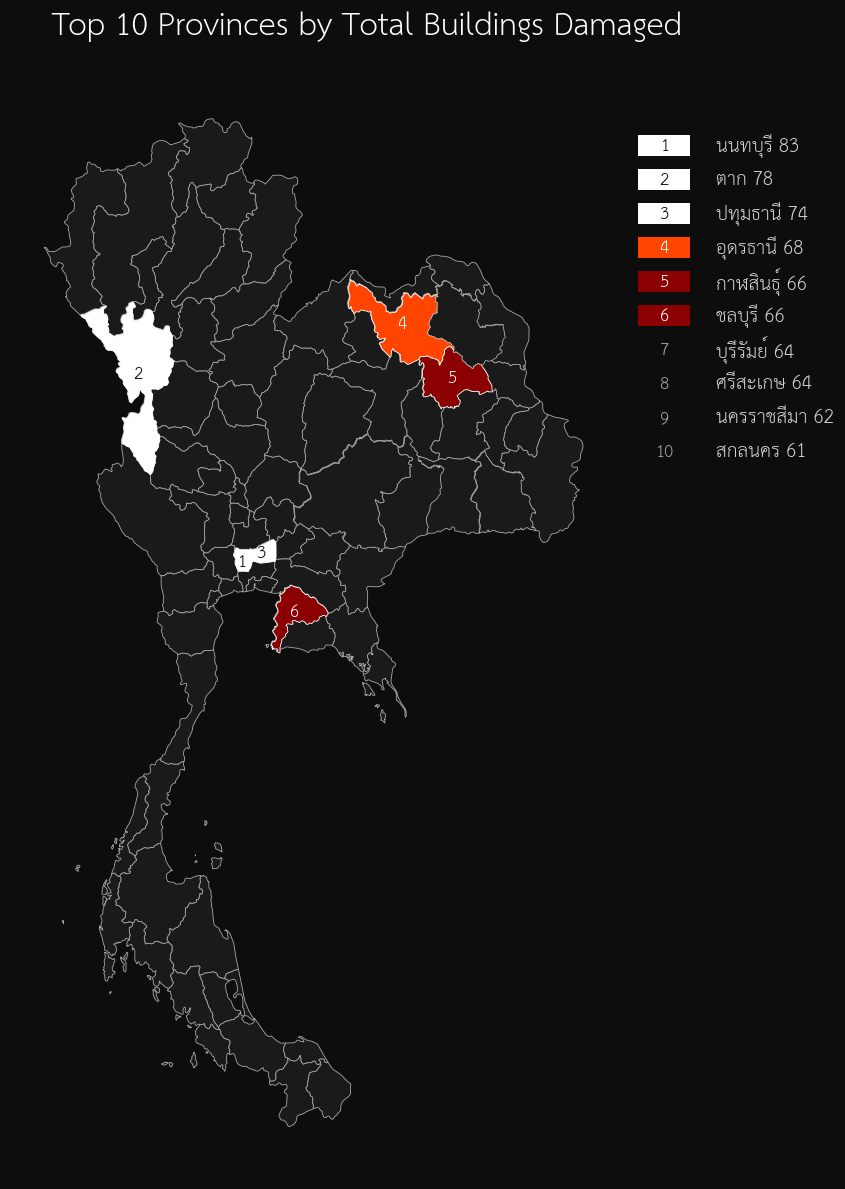

In [ ]:
#โหลดแผนที่ประเทศไทย
url = "https://raw.githubusercontent.com/apisit/thailand.json/master/thailand.json"

try:
    urllib.request.urlretrieve(url, "thailand.json")
    thmap = gpd.read_file("thailand.json")

    # เพิ่มชื่อจังหวัดภาษาไทยใน GeoDataFrame
    thmap['province'] = thmap['name'].map(en_to_th)

except Exception as e:
    print("โหลดแผนที่ตกระหว่างดาวน์โหลด ไม่สามารถพล็อตได้:", e)

#รวมข้อมูลแผนที่กับข้อมูล Top 10 จังหวัด
map_data_prov = thmap.merge(top10_prov, on='province', how='left')

# สีสำหรับอันดับ 1-6
color_palette = ['#FFFFFF', '#FFFFFF', '#FFFFFF', '#FF4500', '#8B0000', '#8B0000']

#สร้างแผนที่
fig, ax = plt.subplots(figsize=(15, 12), facecolor='#0D0D0D')
ax.set_facecolor('#0D0D0D')
ax.axis('off')

ax.set_title(
    'Top 10 Provinces by Total Buildings Damaged',
    color='white',
    fontsize=18,
    pad=20
)

# วาดแผนที่พื้นฐาน
thmap.plot(ax=ax, color='#1A1A1A', edgecolor='darkgrey', linewidth=0.5)

# ตำแหน่ง legend
legend_x = 106.5
legend_y_start = 20.0
y_step = -0.5

# ไฮไลต์ Top 10 จังหวัด
for i, row in top10_prov.iterrows():
    rank = i + 1
    prov_name = row['province']
    total = row['total_damage']

    prov_geom = thmap[thmap['province'] == prov_name]

    if not prov_geom.empty:
        if rank <= 6:
            bg_color = color_palette[rank - 1]
            text_color = 'black' if bg_color == '#FFFFFF' else 'white'

            # ระบายสีจังหวัด
            prov_geom.plot(ax=ax, color=bg_color, edgecolor='white', linewidth=0.5)

            # ใส่เลขอันดับบนแผนที่
            centroid = prov_geom.geometry.centroid.iloc[0]
            ax.text(
                centroid.x, centroid.y, str(rank),
                color=text_color, fontsize=10,
                ha='center', va='center', weight='bold'
            )

            # กล่องอันดับใน legend
            rect = patches.Rectangle(
                (legend_x, legend_y_start + (i * y_step) - 0.1),
                0.8, 0.3,
                facecolor=bg_color,
                edgecolor='none'
            )
            ax.add_patch(rect)

            ax.text(
                legend_x + 0.4,
                legend_y_start + (i * y_step) + 0.05,
                str(rank),
                color=text_color,
                fontsize=10,
                ha='center',
                va='center'
            )
        else:
            # อันดับ 7-10 ใช้สีพื้นเดิม
            prov_geom.plot(ax=ax, color='#1A1A1A', edgecolor='darkgrey', linewidth=0.5)

            ax.text(
                legend_x + 0.4,
                legend_y_start + (i * y_step) + 0.05,
                str(rank),
                color='darkgrey',
                fontsize=10,
                ha='center',
                va='center'
            )

        # ข้อความชื่อจังหวัด + ค่าความเสียหาย
        label_text = f"{prov_name} {total:.0f}"
        ax.text(
            legend_x + 1.2,
            legend_y_start + (i * y_step) + 0.05,
            label_text,
            color='lightgrey',
            fontsize=11,
            ha='left',
            va='center'
        )

plt.show()

#### สรุปความเสียหายกระจุกตัวระดับจังหวัด

แผนที่นี้แสดงจังหวัดที่มี **จำนวนสิ่งปลูกสร้างเสียหายรวมสูงที่สุด** จากเหตุอัคคีภัยตลอดปี เพื่อใช้ระบุ “จุดวิกฤตเชิงพื้นที่” ในระดับจังหวัด

### Pattern ที่เห็นชัดจากแผนที่

**นนทบุรี** — เป็นจังหวัดที่มีจำนวนสิ่งปลูกสร้างเสียหายรวมสูงที่สุดในชุดข้อมูล สะท้อนว่าเป็นพื้นที่ที่ความเสียหายจากอัคคีภัย “กระจุกตัว” เด่นที่สุดในระดับจังหวัด โดยมีลักษณะเป็นพื้นที่เมืองหนาแน่นและมีมูลค่าทรัพย์สินสูง จึงอาจได้รับผลกระทบสะสมมากกว่าจังหวัดทั่วไป

**ตาก** — อยู่ในอันดับต้นของประเทศเช่นกัน สะท้อนว่าความเสียหายจำนวนมากไม่ได้เกิดเฉพาะในพื้นที่เมืองใหญ่เท่านั้น แต่สามารถเกิดในจังหวัดที่มีลักษณะพื้นที่กว้างหรือมีโครงสร้างชุมชนกระจายตัวได้เช่นกัน

**พระนครศรีอยุธยา, หนองบัวลำภู, นครพนม, สระบุรี, อุบลราชธานี, ศรีสะเกษ, อำนาจเจริญ, ชัยภูมิ** — เป็นกลุ่มจังหวัดที่ติดอันดับ Top 10 และสะท้อนว่าความเสียหายสะสมไม่ได้กระจุกเพียงภาคเดียว แต่มีทั้งภาคกลางและภาคตะวันออกเฉียงเหนือปรากฏเด่นอย่างชัดเจน

### ข้อสรุป

เมื่อพิจารณาในระดับจังหวัด จุดที่ความเสียหายสะสมกระจุกตัวสูงที่สุดคือ **นนทบุรี** ซึ่งสามารถตีความได้ว่าเป็น “hotspot ระดับจังหวัด” ขณะเดียวกันการที่หลายจังหวัดในภาคตะวันออกเฉียงเหนือปรากฏอยู่ใน Top 10 ก็สะท้อนว่าความเสียหายจากอัคคีภัยในภูมิภาคนี้ไม่ได้เกิดขึ้นเพียงจังหวัดเดียว แต่เป็นรูปแบบความเสียหายที่กระจายตัวอยู่หลายพื้นที่และมีน้ำหนักรวมสูง ในระดับภูมิภาค

In [ ]:
# ใส่ภูมิภาค, จัดการจังหวัดที่ไม่มีแผนที่ (เช่น ระบุไม่ได้) เป็น 'ไม่ระบุ'
df_q2['region'] = df_q2['province'].map(region_mapping).fillna('ไม่ระบุ')

# รวมการเสียหายของสิ่งปลูกสร้างแต่ละประเภทตามภูมิภาค
df_building = df_q2.groupby('region')[building_types].sum().reset_index()

# ละลาย (Melt) ให้เป็น Long Format สำหรับวาดกราฟ Sunburst หรือ Treemap
df_building_melt = df_building.melt(id_vars=['region'], value_vars=building_types,
                                    var_name='building_type', value_name='damage_count')

# เอาเฉพาะที่ถูกทำลายจริง (>0)
df_building_melt = df_building_melt[df_building_melt['damage_count'] > 0]
# กรองกลุ่ม 'ไม่ระบุ' ออกไปเพี่อไม่ให้แย่งสัดส่วนในกราฟ
df_building_melt = df_building_melt[df_building_melt['region'] != 'ไม่ระบุ']


df_building_melt['building_type_th'] = df_building_melt['building_type'].map(building_labels_th)

fig2 = px.treemap(df_building_melt, path=[px.Constant('ส่วนของสิ่งปลูกสร้างทั่วประเทศ'), 'region', 'building_type_th'],
                  values='damage_count',
                  title='การกระจายตัวของความเสียหาย (ประเภทของสิ่งปลูกสร้าง แยกตามภูมิภาค)',
                  color='damage_count', color_continuous_scale='Reds')

fig2.show()

#### สรุปความเสียหายกระจุกตัวระดับภูมิภาคและประเภทสิ่งปลูกสร้าง

กราฟ Treemap นี้ช่วยขยายความเข้าใจจากระดับจังหวัดไปสู่ระดับ **ภูมิภาค** และ **ประเภทของสิ่งปลูกสร้าง** โดยทำให้เห็นพร้อมกันว่า ความเสียหายกระจุกอยู่ในภูมิภาคใด และเกิดกับสิ่งปลูกสร้างประเภทใดมากที่สุด

### Pattern ที่เห็นชัดจากกราฟ

**ภาคตะวันออกเฉียงเหนือ** — เป็นภูมิภาคที่มีจำนวนความเสียหายรวมสูงที่สุดในภาพรวม สะท้อนว่าแม้จังหวัดที่รุนแรงที่สุดรายจุดจะเป็นนนทบุรี แต่เมื่อรวมทั้งภูมิภาคแล้ว ภาคตะวันออกเฉียงเหนือแบกรับภาระความเสียหายสะสมมากที่สุด

**ภาคกลาง** — เป็นภูมิภาคที่มีความเสียหายรวมสูงรองลงมา และมีบทบาทเด่นในกลุ่มสิ่งปลูกสร้างประเภทบ้านเรือนเสียหายบางส่วน สะท้อนลักษณะของพื้นที่ชุมชนเมืองและกึ่งเมืองที่มีความหนาแน่นของที่อยู่อาศัยสูง

**บ้านเรือนเสียหายทั้งหลัง** — เป็นประเภทสิ่งปลูกสร้างที่ได้รับผลกระทบมากที่สุดในภาพรวมของประเทศ และเด่นชัดมากในภาคตะวันออกเฉียงเหนือ แสดงให้เห็นว่าอัคคีภัยในหลายพื้นที่ไม่ได้สร้างผลกระทบเพียงผิวเผิน แต่ทำลายที่อยู่อาศัยในระดับรุนแรง

**บ้านเรือนเสียหายบางส่วน** — เป็นประเภทที่มีสัดส่วนสูงรองลงมา โดยเฉพาะในภาคกลางและภาคตะวันออกเฉียงเหนือ สะท้อนว่าผลกระทบจากอัคคีภัยจำนวนมากเกิดในระดับที่ยังไม่ถึงขั้นสูญเสียทั้งหลัง แต่กระทบต่อคุณภาพชีวิตและความมั่นคงของครัวเรือนอย่างมาก

**อาคาร, ร้านค้า, อาคารพาณิชย์, ที่พักชั่วคราว** — เป็นกลุ่มสิ่งปลูกสร้างที่มีความเสียหายรองลงมา แสดงว่าผลกระทบไม่ได้จำกัดอยู่เฉพาะที่อยู่อาศัย แต่ยังลามไปถึงกิจกรรมทางเศรษฐกิจและโครงสร้างชุมชนด้วย

### ข้อสรุป

กราฟนี้เผยให้เห็นว่า ความเสียหายจากอัคคีภัยมีลักษณะกระจุกตัวชัดเจนทั้งในเชิงภูมิภาคและเชิงประเภทสิ่งปลูกสร้าง โดย  
- ในระดับ **ภูมิภาค** ภาคตะวันออกเฉียงเหนือมีภาระความเสียหายสะสมสูงที่สุด  
- ในระดับ **จังหวัด** นนทบุรีเป็น hotspot ที่เด่นที่สุด  
- ในระดับ **ประเภทสิ่งปลูกสร้าง** บ้านเรือนเสียหายทั้งหลังและบ้านเรือนเสียหายบางส่วนคือกลุ่มที่ได้รับผลกระทบมากที่สุด

จุดวิกฤตของอัคคีภัยในปี 2562 ไม่ได้สะท้อนเพียง พื้นที่ที่เกิดเหตุ แต่สะท้อนถึง ความเปราะบางของที่อยู่อาศัยอย่างเด่นชัด โดยเฉพาะในภูมิภาคที่มีชุมชนขนาดใหญ่และการกระจายตัวของครัวเรือนหนาแน่น

###5.3  คำถามที่ 3: อะไรคือตัวชี้วัดความรุนแรง? (Severity Predictors)\nวิเคราะห์ความสัมพันธ์ (Correlation) ขององค์ประกอบต่างๆ ว่าสิ่งใดส่งผลต่อจำนวนผู้บาดเจ็บ/เสียชีวิต หรือมูลค่าความเสียหายสูง

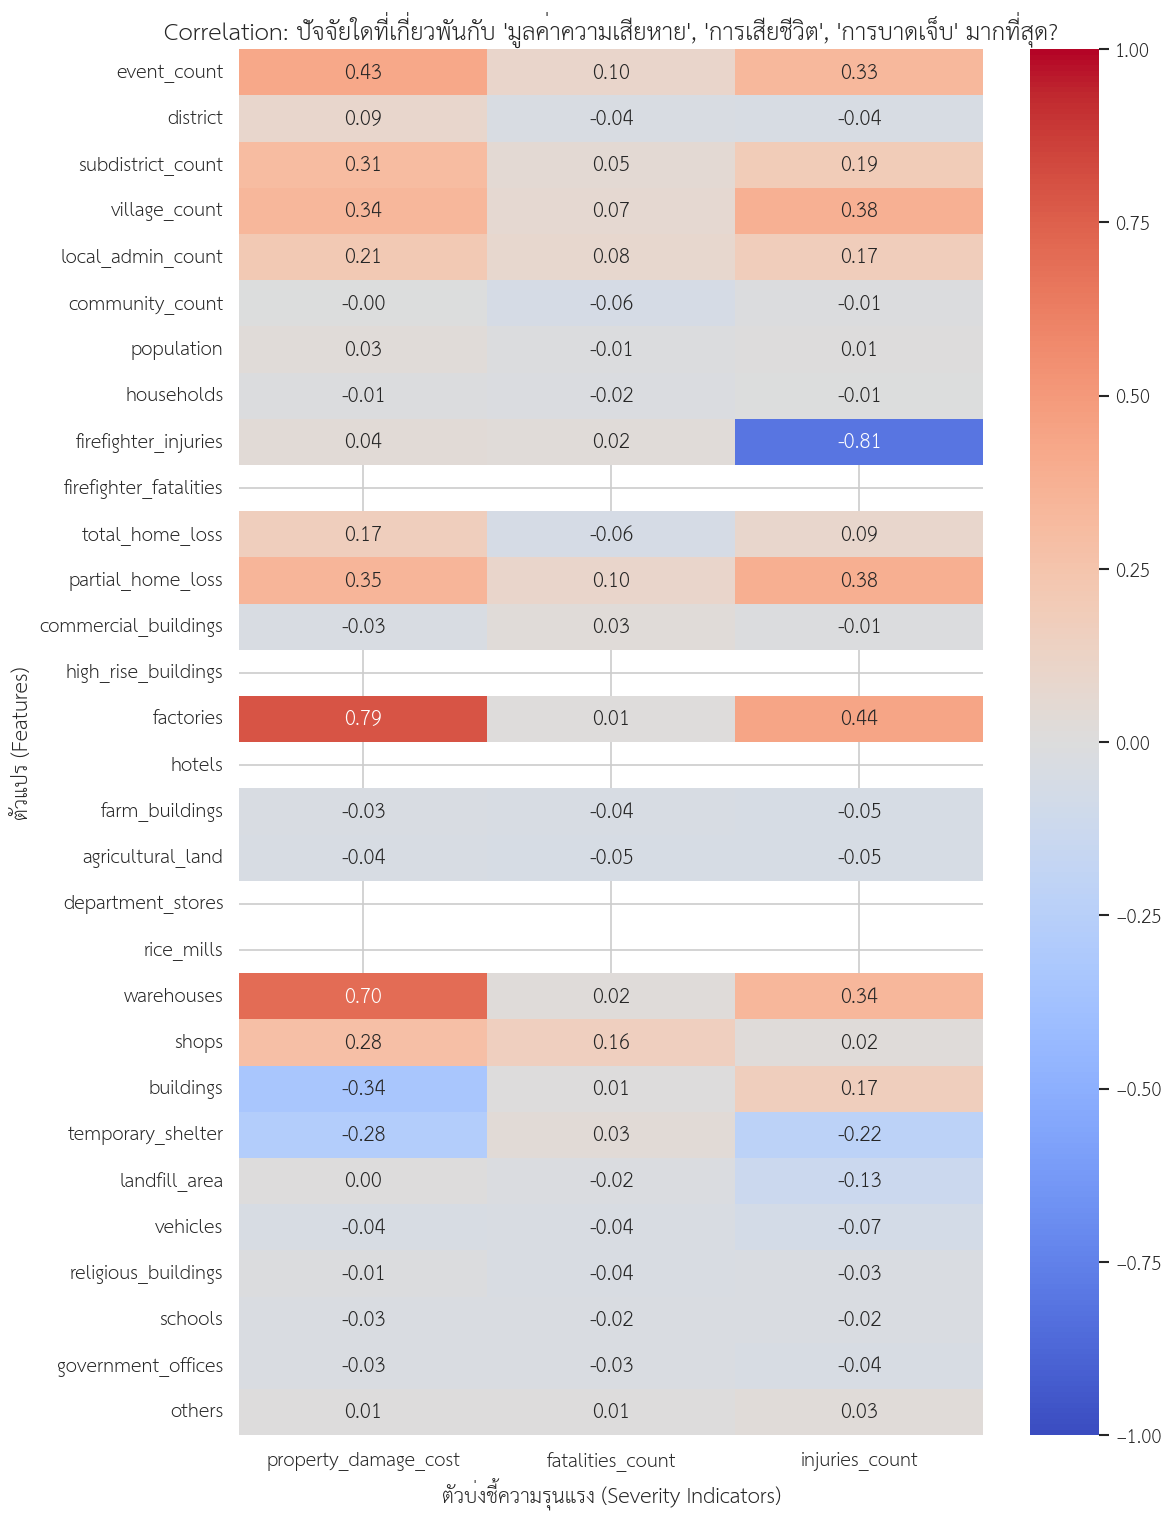

In [ ]:
# กำหนดตัวบ่งชี้ความรุนแรงได้แก่ 'property_damage_cost', 'fatalities_count', 'injuries_count'
targets = ['property_damage_cost', 'fatalities_count', 'injuries_count']
# หาความสัมพันธ์แบบ Pearson Correlation
corr_matrix = df_q2[numeric_cols].corr()
# ดึงเฉพาะความสัมพันธ์ที่เกี่ยวข้องกับ Target
target_corr = corr_matrix[targets].drop(targets, axis=0)

# แสดงผล Heatmap ความสัมพันธ์
plt.figure(figsize=(10, 15))
sns.heatmap(target_corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation: ปัจจัยใดที่เกี่ยวพันกับ 'มูลค่าความเสียหาย', 'การเสียชีวิต', 'การบาดเจ็บ' มากที่สุด?", fontsize=14)
plt.ylabel('ตัวแปร (Features)')
plt.xlabel('ตัวบ่งชี้ความรุนแรง (Severity Indicators)')
plt.show()

# นอกจากนี้เรายังนำปัจจัยที่สัมพันธ์สูงสุดมาวาดกราฟแท่งแบบง่ายๆ (Top 10 ของ Damage Cost)
top10_damage = target_corr['property_damage_cost'].abs().sort_values(ascending=False).head(10)
top10_details = target_corr.loc[top10_damage.index, 'property_damage_cost']

fig3 = px.bar(x=top10_details.values, y=top10_details.index, orientation='h',
             title='10 อันดับตัวแปรที่ส่งผลเชิงบวก/ลบ สูงสุดต่อ "มูลค่าความเสียหาย" (Correlation)',
             labels={'x': 'ค่าความสัมพันธ์ (Correlation Coefficient)', 'y': 'ตัวแปร (Features)'},
             color=top10_details.values, color_continuous_scale='RdYlGn')

# ทำให้เรียงจากมากไปน้อย
fig3.update_layout(yaxis=dict(autorange="reversed"))
fig3.show()

#### สรุป Severity Predictors

การวิเคราะห์ความสัมพันธ์ (Correlation) ในส่วนนี้มีเป้าหมายเพื่อดูว่า ปัจจัยใดในระดับจังหวัดมีแนวโน้มสัมพันธ์กับ “ความรุนแรง” ของอัคคีภัยมากที่สุด โดยใช้ตัวชี้วัดความรุนแรง 3 ด้าน ได้แก่  
**มูลค่าความเสียหาย**, **จำนวนผู้เสียชีวิต**, และ **จำนวนผู้บาดเจ็บ**

### Pattern ที่เห็นชัดจาก Heatmap

**มูลค่าความเสียหาย (property_damage_cost)** — มีความสัมพันธ์เชิงบวกสูงกับ  
- **จำนวนโรงงาน (factories)** ประมาณ **0.79**  
- **จำนวนโกดัง/คลังสินค้า (warehouses)** ประมาณ **0.70**  
- **จำนวนเหตุการณ์ (event_count)** ประมาณ **0.43**  
- **บ้านเรือนเสียหายบางส่วน (partial_home_loss)** ประมาณ **0.35**

สะท้อนว่า ความเสียหายทางเศรษฐกิจที่สูงมักสัมพันธ์กับพื้นที่ที่มีโครงสร้างพื้นฐานทางเศรษฐกิจและการเก็บสินค้า เช่น โรงงานและโกดัง มากกว่าปัจจัยด้านประชากรเพียงอย่างเดียว

**จำนวนผู้บาดเจ็บ (injuries_count)** — มีความสัมพันธ์เชิงบวกเด่นกับ  
- **จำนวนโรงงาน (factories)** ประมาณ **0.44**  
- **จำนวนหมู่บ้าน (village_count)** ประมาณ **0.38**  
- **บ้านเรือนเสียหายบางส่วน (partial_home_loss)** ประมาณ **0.38**  
- **จำนวนเหตุการณ์ (event_count)** ประมาณ **0.33**  
- **จำนวนโกดัง (warehouses)** ประมาณ **0.34**

สะท้อนว่าการบาดเจ็บมีแนวโน้มสัมพันธ์กับพื้นที่ที่มีทั้งกิจกรรมเศรษฐกิจและการกระจายตัวของชุมชนในระดับสูง กล่าวคือ ยิ่งพื้นที่มีโครงสร้างชุมชนและสิ่งปลูกสร้างหนาแน่นมากเท่าไร โอกาสที่เหตุการณ์จะกระทบต่อคนก็ยิ่งสูงขึ้น

**จำนวนผู้เสียชีวิต (fatalities_count)** — โดยรวมมีความสัมพันธ์กับตัวแปรต่าง ๆ ค่อนข้างต่ำเมื่อเทียบกับอีกสองตัวชี้วัด สะท้อนว่าการเสียชีวิตอาจไม่ได้ขึ้นกับขนาดของพื้นที่หรือจำนวนสิ่งปลูกสร้างเพียงอย่างเดียว แต่ขึ้นอยู่กับปัจจัยเฉพาะเหตุการณ์ เช่น เวลาเกิดเหตุ ความพร้อมของการอพยพ การเข้าถึงระบบดับเพลิง หรือสภาพแวดล้อม ณ จุดเกิดเหตุ ซึ่งไม่มีอยู่ในชุดข้อมูลนี้

### Pattern ที่เห็นชัดจากกราฟแท่ง Top Correlation ของมูลค่าความเสียหาย

กราฟแท่งยืนยันผลจาก Heatmap อย่างชัดเจนว่า **โรงงาน** และ **โกดัง** คือสองตัวแปรที่สัมพันธ์กับมูลค่าความเสียหายสูงที่สุดอย่างโดดเด่น ตามมาด้วย **จำนวนเหตุการณ์**, **บ้านเรือนเสียหายบางส่วน**, และตัวแปรที่สะท้อนขนาดของชุมชน เช่น **จำนวนหมู่บ้าน** และ **จำนวนตำบล**

ในทางกลับกัน ตัวแปรบางตัว เช่น **buildings** และ **temporary_shelter** มีความสัมพันธ์เชิงลบกับมูลค่าความเสียหาย ซึ่งอาจสะท้อนว่าการมีจำนวนสิ่งปลูกสร้างบางประเภทมาก ไม่ได้แปลว่าจะมีมูลค่าความเสียหายสูงเสมอไป หรืออาจเกิดจากโครงสร้างการกระจายตัวของข้อมูลในแต่ละจังหวัด

### ข้อสรุป

Heatmap และกราฟแท่งร่วมกันชี้ให้เห็นว่า “ความรุนแรง” ของอัคคีภัยในเชิงมูลค่าความเสียหายและการบาดเจ็บ มีความเชื่อมโยงชัดเจนกับ **โครงสร้างพื้นฐานทางเศรษฐกิจ** และ **ความหนาแน่นของชุมชน** มากกว่าตัวแปรประชากรพื้นฐานทั่วไป

กล่าวอีกนัยหนึ่ง หากต้องออกแบบระบบเฝ้าระวังหรือระบบเตือนภัยล่วงหน้า ตัวแปรที่ควรจับตาเป็นอันดับต้น ๆ คือ  
**จำนวนโรงงาน, จำนวนโกดัง, จำนวนเหตุการณ์, จำนวนหมู่บ้าน, และความเสียหายต่อที่อยู่อาศัย**  
เพราะตัวแปรเหล่านี้สัมพันธ์กับทั้งมูลค่าความเสียหายและการบาดเจ็บอย่างชัดเจน

ผลลัพธ์นี้ควรถูกตีความว่าเป็น **ความสัมพันธ์เชิงสถิติ** ไม่ใช่การยืนยันเหตุและผลโดยตรง เนื่องจากข้อมูลนี้เป็นข้อมูลสรุประดับจังหวัด ไม่ใช่ข้อมูลรายเหตุการณ์ ดังนั้นจึงเหมาะสำหรับใช้เป็น “ตัวชี้วัดเบื้องต้น” เพื่อสนับสนุนการวางนโยบาย มากกว่าการสรุปว่าเป็นสาเหตุโดยตรงของความรุนแรง